In [241]:
import pandas as pd
import geopandas as gpd
import pandas_geojson as pdg
import matplotlib.pyplot as plt
import requests
import scipy
import seaborn as sns

In [143]:
data_centre_data = pd.read_csv("ukpn-data-centre-utilisation.csv")
data_centre_data.drop('Anonymised Name', axis=1, inplace=True)

FileNotFoundError: [Errno 2] No such file or directory: 'ukpn-data-centre-utilisation.csv'

In [144]:
power_plants_england = pd.read_csv("data\global_power_plant_database.csv")
power_plants_england = power_plants_england[power_plants_england['country']=='GBR']


C:\Users\acebi\AppData\Local\Temp\ipykernel_7024\1225399312.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  power_plants_england = pd.read_csv("data\global_power_plant_database.csv")


In [145]:
energy_distrib = gpd.read_file('data/energy_distribution_areas.geojson')

In [ ]:
# energy_distrib['extent'] = energy_distrib['geometry'].area

In [262]:
power_plants_england.columns

Index(['country', 'country_long', 'name', 'gppd_idnr', 'capacity_mw',
       'latitude', 'longitude', 'primary_fuel', 'other_fuel1', 'other_fuel2',
       'other_fuel3', 'commissioning_year', 'owner', 'source', 'url',
       'geolocation_source', 'wepp_id', 'year_of_capacity_data',
       'generation_gwh_2013', 'generation_gwh_2014', 'generation_gwh_2015',
       'generation_gwh_2016', 'generation_gwh_2017', 'generation_gwh_2018',
       'generation_gwh_2019', 'generation_data_source',
       'estimated_generation_gwh_2013', 'estimated_generation_gwh_2014',
       'estimated_generation_gwh_2015', 'estimated_generation_gwh_2016',
       'estimated_generation_gwh_2017', 'estimated_generation_note_2013',
       'estimated_generation_note_2014', 'estimated_generation_note_2015',
       'estimated_generation_note_2016', 'estimated_generation_note_2017',
       'geometry'],
      dtype='object')

In [146]:
# translate power plant data into geodataframe
power_plants_england['geometry'] = gpd.points_from_xy(power_plants_england.longitude, power_plants_england.latitude, crs="EPSG:4326")
geo_power_plants = gpd.GeoDataFrame(data=power_plants_england, geometry='geometry')
geo_power_plants = geo_power_plants.to_crs(energy_distrib.crs)

In [147]:
# join info to allow power plant info to be join with corresponding dno
power_plants_distrib = gpd.sjoin(left_df=geo_power_plants, right_df=energy_distrib, how='left', predicate='within')

In [160]:
# find unassigned power stations and separate into separate dataset
na_vals = power_plants_distrib[power_plants_distrib['Area'].isna()]
power_plants_distrib.drop(power_plants_distrib[power_plants_distrib['Area'].isna()].index, inplace=True)
# clean data - drop NI power stations and others outside DNO authority; drop columns from energy_distrib
na_vals.drop(columns=['index_right', 'ID', 'Name', 'DNO', 'Area', 'DNO_Full'], inplace=True)
na_vals.drop(na_vals[(na_vals['longitude'] < -10) & (na_vals['latitude'] < 50)].index, inplace=True)
na_vals.drop(na_vals[(na_vals['longitude'] < -5) & (na_vals['latitude'] > 53) & (na_vals['latitude'] < 55.5)].index, inplace=True)

C:\Users\acebi\AppData\Local\Temp\ipykernel_7024\796441991.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  na_vals.drop(columns=['index_right', 'ID', 'Name', 'DNO', 'Area', 'DNO_Full'], inplace=True)
C:\Users\acebi\AppData\Local\Temp\ipykernel_7024\796441991.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  na_vals.drop(na_vals[(na_vals['longitude'] < -10) & (na_vals['latitude'] < 50)].index, inplace=True)
C:\Users\acebi\AppData\Local\Temp\ipykernel_7024\796441991.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.

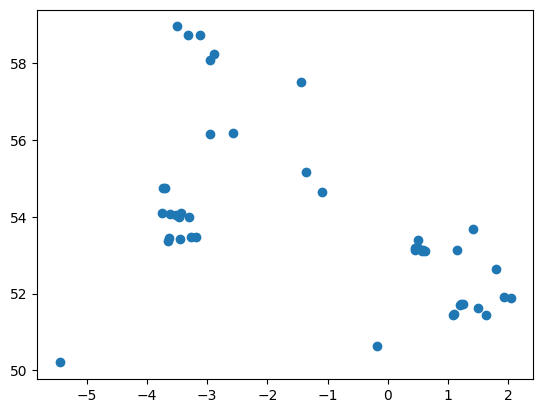

In [161]:
# visualise outstanding points and source of outstanding energy
na_vals.value_counts()
plt.scatter(na_vals['longitude'], na_vals['latitude'])

In [162]:
# attribute offshore energy to nearest dno
offshore_power_plants_distrib = gpd.sjoin_nearest(na_vals, energy_distrib)

In [180]:
# concat the datasets and sort
power_plants_full = pd.concat([power_plants_distrib, offshore_power_plants_distrib])
power_plants_full.sort_index()

,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017,geometry,index_right,ID,Name,DNO,Area,DNO_Full
21961,GBR,United Kingdom,30 Acres,GBR0005396,4.965,53.2062,-1.1968,Solar,NaN,NaN,...,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,POINT (453744.305 367982.13),1.0,11.0,_B,NGED,East Midlands,National Grid Electricity Distribution
21962,GBR,United Kingdom,A C Shropshire (Farm AD),GBR0000233,2.500,52.5860,-1.2375,Biomass,NaN,NaN,...,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,POINT (451757.978 298961.089),1.0,11.0,_B,NGED,East Midlands,National Grid Electricity Distribution
21963,GBR,United Kingdom,A'Chruach,GBR0004331,42.600,56.1528,-5.3102,Wind,NaN,NaN,...,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (194501.181 700503.555),7.0,17.0,_P,SSEN,North Scotland,Scottish and Southern Electricity Networks
21964,GBR,United Kingdom,ABP Ellesmere Abbatoir,GBR0006488,1.100,52.8543,-2.8986,Biomass,NaN,NaN,...,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,POINT (339587.865 328912.328),3.0,13.0,_D,SPEN,"North Wales, Merseyside and Cheshire",SP Energy Networks
21965,GBR,United Kingdom,AMBLESTON SOLAR PANELS,GBR0001623,6.000,51.8992,-4.8665,Solar,NaN,NaN,...,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,POINT (202882.094 226179.254),9.0,21.0,_K,NGED,South Wales,National Grid Electricity Distribution
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24705,GBR,United Kingdom,Yerbeston Gate Farm,GBR0002365,6.100,51.7473,-4.7945,Solar,NaN,NaN,...,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,POINT (207186.581 209096.541),9.0,21.0,_K,NGED,South Wales,National Grid Electricity Distribution
24706,GBR,United Kingdom,Yonderton Farm,GBR0003723,1.000,57.4308,-1.9419,Wind,NaN,NaN,...,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (403587.753 837829.897),7.0,17.0,_P,SSEN,North Scotland,Scottish and Southern Electricity Networks
24707,GBR,United Kingdom,Yonderton Wind Cluster,GBR0003836,4.600,57.5870,-2.4166,Wind,NaN,NaN,...,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (375190.73 855294.352),7.0,17.0,_P,SSEN,North Scotland,Scottish and Southern Electricity Networks
24708,GBR,United Kingdom,Yorkley Solar Park,GBR0005243,5.000,51.7459,-2.5356,Solar,NaN,NaN,...,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,POINT (363118.715 205380.388),4.0,14.0,_E,NGED,West Midlands,National Grid Electricity Distribution


In [187]:
power_plants_full_energy_mix = (power_plants_full.groupby(['Area', 'primary_fuel'])['capacity_mw'].sum())


In [203]:
power_plants_full_energy_mix[:11]

Area           primary_fuel
East England   Biomass          269.50000
               Gas             3320.00000
               Nuclear         1198.00000
               Solar           1521.91466
               Storage           69.00000
               Waste            259.40000
               Wind            3674.28820
East Midlands  Biomass          148.50000
               Coal            6020.00000
               Gas             5673.00000
               Hydro              1.70000
Name: capacity_mw, dtype: float64

In [234]:
# calculate power plant capacity per region
regional_total = dict()
for index in power_plants_full_energy_mix.index:
    if index[0] in regional_total.keys():
            regional_total[index[0]] += power_plants_full_energy_mix[power_plants_full_energy_mix.index==index].values[0] 
    else: 
        regional_total[index[0]] = power_plants_full_energy_mix[power_plants_full_energy_mix.index==index].values[0]

# calculate fuel mix
power_plants_full_energy_mix = pd.DataFrame(power_plants_full_energy_mix)
power_plants_full_energy_mix['capacity_pct'] = None
for index, row in power_plants_full_energy_mix.iterrows():
    power_plants_full_energy_mix.loc[index, 'capacity_pct'] = row['capacity_mw'] / regional_total[index[0]]

In [237]:
power_plants_distrib[power_plants_distrib['primary_fuel']=='Gas']

,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017,geometry,index_right,ID,Name,DNO,Area,DNO_Full
21976,GBR,United Kingdom,Aberthaw GT,GBR1000375,51.0,51.3875,-3.4068,Gas,NaN,NaN,...,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (302205.809 166323.522),9.0,21.0,_K,NGED,South Wales,National Grid Electricity Distribution
22088,GBR,United Kingdom,Baglan Bay CCGT,GBR1000312,520.0,51.6145,-3.8352,Gas,NaN,NaN,...,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (273031.097 192226.024),9.0,21.0,_K,NGED,South Wales,National Grid Electricity Distribution
22089,GBR,United Kingdom,Baglan Bay OCGT,GBR1000314,32.3,51.5924,-3.7802,Gas,NaN,NaN,...,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (276779.029 189674.15),9.0,21.0,_K,NGED,South Wales,National Grid Electricity Distribution
22126,GBR,United Kingdom,Barry,GBR2000125,235.0,51.4089,-3.2301,Gas,NaN,NaN,...,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (314540.801 168482.239),9.0,21.0,_K,NGED,South Wales,National Grid Electricity Distribution
22217,GBR,United Kingdom,Blackburn,GBR1000464,59.0,53.7500,-2.4833,Gas,NaN,NaN,...,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (368227.108 428289.658),6.0,16.0,_G,ENWL,North West England,Electricity North West
22419,GBR,United Kingdom,Carrington,GBR2000124,900.0,53.4366,-2.4077,Gas,NaN,NaN,...,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (373012.586 393390.951),6.0,16.0,_G,ENWL,North West England,Electricity North West
22433,GBR,United Kingdom,Castleford,GBR1000113,56.0,53.7259,-1.3626,Gas,NaN,NaN,...,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (442153.787 425688.243),11.0,23.0,_M,NPG,Yorkshire,Northern Powergrid
22483,GBR,United Kingdom,Chippenham,GBR1000440,10.0,51.4600,-2.1247,Gas,NaN,NaN,...,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (391433.015 173454.55),13.0,20.0,_H,SSEN,Southern England,Scottish and Southern Electricity Networks
22546,GBR,United Kingdom,Connahs Quay,GBR1000492,1380.0,53.2317,-3.0815,Gas,NaN,NaN,...,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (327905.688 371064.138),3.0,13.0,_D,SPEN,"North Wales, Merseyside and Cheshire",SP Energy Networks
22556,GBR,United Kingdom,Corby,GBR1000077,401.0,52.5104,-0.6814,Gas,NaN,NaN,...,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,POINT (489587.13 291095.566),1.0,11.0,_B,NGED,East Midlands,National Grid Electricity Distribution


In [235]:
power_plants_full_energy_mix

capacity_mw capacity_pct
Area         primary_fuel                          
East England Biomass         269.50000     0.026134
             Gas            3320.00000     0.321952
             Nuclear        1198.00000     0.116174
             Solar          1521.91466     0.147585
             Storage          69.00000     0.006691
...                                ...          ...
Yorkshire    Gas            3466.00000     0.347572
             Solar           172.55980     0.017304
             Storage          49.90000     0.005004
             Waste            89.60000     0.008985
             Wind            671.38400     0.067327

[105 rows x 2 columns]

In [253]:
rci = pd.read_csv('data/regional_carbon_intensity.csv')
rci = rci[-100:]
rci.set_index(rci['datetime'], inplace=True)
# rci.drop(['datetime'], inplace=True)

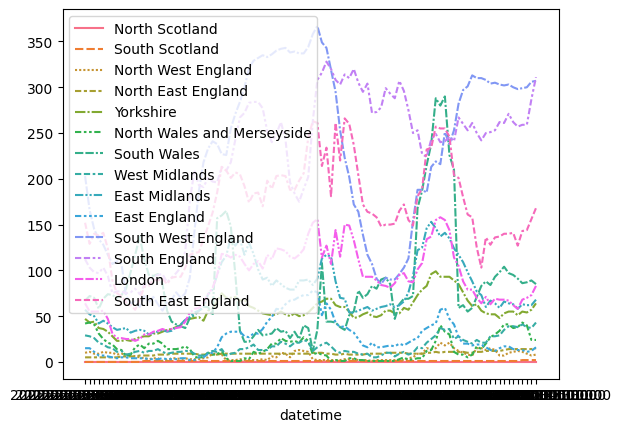

In [261]:
cols = []
for region in rci.columns[1:]:
    cols.append(region)

fig = sns.lineplot(data=rci[cols])


In [213]:
regional_total

{'East England': np.float64(10312.102859999999),
 'East Midlands': np.float64(14566.753470000001),
 'London': np.float64(297.80370999999997),
 'North East England': np.float64(2194.5304),
 'North Scotland': np.float64(8294.54784),
 'North Wales, Merseyside and Cheshire': np.float64(8828.69766),
 'North West England': np.float64(6064.4144),
 'South East England': np.float64(6748.75743),
 'South Wales': np.float64(7292.9086),
 'South West England': np.float64(4964.833380000001),
 'South and Central Scotland': np.float64(7518.799999999999),
 'Southern England': np.float64(5399.85439),
 'West Midlands': np.float64(826.47766),
 'Yorkshire': np.float64(9972.043800000001)}

In [ ]:
# BLOCK CODE
# data_centre_data = pd.read_csv("ukpn-data-centre-utilisation.csv")
# data_centre_data.drop('Anonymised Name', axis=1, inplace=True)

# power_plants_england = pd.read_csv("data\global_power_plant_database.csv")
# power_plants_england = power_plants_england[power_plants_england['country']=='GBR']

# energy_distrib = gpd.read_file('data/energy_distribution_areas.geojson')

# # translate power plant data into geodataframe
# power_plants_england['geometry'] = gpd.points_from_xy(power_plants_england.latitude, power_plants_england.longitude, crs="EPSG:27700")
# geo_power_plants = gpd.GeoDataFrame(data=power_plants_england, geometry='geometry')

# power_plants_distrib = gpd.sjoin(left_df=geo_power_plants, right_df=energy_distrib, how='inner', predicate='within')


C:\Users\acebi\AppData\Local\Temp\ipykernel_7024\1518910396.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  power_plants_england = pd.read_csv("data\global_power_plant_database.csv")
